In [1]:
!pip install mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 495.3 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 940.6 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 28.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 48.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 1.6 MB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.6 MB/s eta 

In [2]:
import pandas as pd
import numpy as np
import mlflow
import dagshub
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

dagshub.init(repo_owner='tvada22', repo_name='ML--Assignment2-IEEE-CIS-Fraud-Detection', mlflow=True)
mlflow.set_experiment("GradientBoosting_Training")

train_df = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=ca793be0-8aaf-458a-a80c-a40c432c85d6&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=146b63f0258c3627a080c8199faf50cdf657ce493cef2af64e883ef426fe184d




Accessing as tvada22

Initialized MLflow to track repo "tvada22/ML--Assignment2-IEEE-CIS-Fraud-Detection"

Repository tvada22/ML--Assignment2-IEEE-CIS-Fraud-Detection initialized!

In [3]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'memory usage of dataframe is {start_mem:.2f} MB')
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max< np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col]= df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max <np.iinfo(np.int32).max:
                    df[col]= df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max< np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col]= df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'memory usage after optimization is: {end_mem:.2f} MB')
    print(f'decreased by {100 * (start_mem-end_mem)/start_mem:.1f}%')
    return df

train_df = reduce_mem_usage(train_df)

memory usage of dataframe is 1775.15 MB


/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overfl

memory usage after optimization is: 542.35 MB
decreased by 69.4%


/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overfl

In [4]:
y = train_df['isFraud']
X = train_df.drop(columns=['isFraud','TransactionID','TransactionDT'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape},X_test shape: {X_test.shape}")


cat_cols = [col for col in X_train.columns if X_train[col].dtype=='object']
num_cols = [col for col in X_train.columns if X_train[col].dtype!= 'object']

print(f"initial categorical columns ({len(cat_cols)}): {cat_cols}")

s = X_train[cat_cols].nunique()
threshold = 3

woe_columns = list(s[s >threshold].index)
one_hot_columns = list(s[s <= threshold].index)

print(f"columns for woe encoding: {woe_columns}")
print(f"columns for one-hot encoding: {one_hot_columns}")

X_train shape: (472432, 391),X_test shape: (118108, 391)
initial categorical columns (14): ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
columns for woe encoding: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']
columns for one-hot encoding: ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


In [5]:
from sklearn.base import BaseEstimator, TransformerMixin

class CustomPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, woe_columns, one_hot_columns):
        self.woe_columns= woe_columns 
        self.one_hot_columns = one_hot_columns 

    def fit(self, X, y):
        self.woe_columns_fill_na = X[self.woe_columns].mode().iloc[0].to_dict()
        
        df_woe = X.copy()
        target_col = 'target'
        df_woe[target_col] = y.values 

        woe_mappings = {}
        iv_values = {}
        
        for col in self.woe_columns:
            groups = df_woe.groupby([col])[target_col].agg(['count', 'sum'])
            groups.columns = ['n_obs', 'n_pos']
            groups['n_neg'] = groups['n_obs'] - groups['n_pos']
            
            groups['prop_pos']= groups['n_pos'] / groups['n_pos'].sum()
            groups['prop_neg'] = groups['n_neg'] / groups['n_neg'].sum()
            
            groups['woe']= np.log(groups['prop_pos'] / groups['prop_neg'])
            groups['iv'] =(groups['prop_pos'] - groups['prop_neg']) * groups['woe']
            
            groups.replace([np.inf, -np.inf], 0, inplace=True)
            groups.fillna(0, inplace=True)
            
            woe_dict = groups['woe'].to_dict()
            iv = groups['iv'].sum()
            
            woe_mappings[col] = woe_dict
            iv_values[col] = iv

        self.woe_mappings =woe_mappings
        self.iv_values = iv_values

        return self

    def transform(self, X):
        X_transformed= X.copy()

        for col in self.woe_columns:
            X_transformed[f'{col}_woe'] = X_transformed[col].map(self.woe_mappings[col])
            X_transformed.drop(columns=col,inplace=True)

        X_transformed = pd.get_dummies(X_transformed, columns=self.one_hot_columns, drop_first=True, dummy_na=True, dtype=int)

        for col in self.woe_columns:
            woe_col_name = f'{col}_woe'
            if X_transformed[woe_col_name].isna().any():
                mode_val = self.woe_columns_fill_na[col]
                fill_val =self.woe_mappings[col].get(mode_val, 0) 
                X_transformed[woe_col_name] = X_transformed[woe_col_name].fillna(fill_val)
                
       
        num_cols_remaining= X_transformed.select_dtypes(include=[np.number]).columns
        X_transformed[num_cols_remaining] =X_transformed[num_cols_remaining].fillna(X_transformed[num_cols_remaining].median())

        return X_transformed

In [6]:
preprocessor = CustomPreprocessor(woe_columns=woe_columns, one_hot_columns=one_hot_columns)

with mlflow.start_run(run_name="GradientBoosting_Cleaning"):
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("woe_threshold",threshold)
    mlflow.log_param("num_woe_columns",len(woe_columns))
    mlflow.log_param("num_ohe_columns", len(one_hot_columns))
    
    X_train_clean= preprocessor.fit_transform(X_train, y_train)
    
    sorted_iv=sorted(preprocessor.iv_values.items(), key=lambda item: item[1],reverse=True)
    for col, iv in sorted_iv[:5]: 
        mlflow.log_metric(f"IV_{col}", iv)
        

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


🏃 View run GradientBoosting_Cleaning at: https://dagshub.com/tvada22/ML--Assignment2-IEEE-CIS-Fraud-Detection.mlflow/#/experiments/5/runs/9cd988589ec7460ea92db87337645e09
🧪 View experiment at: https://dagshub.com/tvada22/ML--Assignment2-IEEE-CIS-Fraud-Detection.mlflow/#/experiments/5



top 20 Features selected by ggradient boosting Importance:
1. V201 (Score: 0.1646)
2. C1 (Score: 0.1212)
3. V258 (Score: 0.0935)
4. C14 (Score: 0.0719)
5. V189 (Score: 0.0592)
6. C13 (Score: 0.0559)
7. V45 (Score: 0.0347)
8. C12 (Score: 0.0331)
9. V317 (Score: 0.0261)
10. C8 (Score: 0.0238)
11. V244 (Score: 0.0161)
12. R_emaildomain_woe (Score: 0.0159)
13. V149 (Score: 0.0152)
14. card6_woe (Score: 0.0130)
15. card3 (Score: 0.0116)
16. V210 (Score: 0.0103)
17. V294 (Score: 0.0101)
18. C4 (Score: 0.0091)
19. V62 (Score: 0.0087)
20. C11 (Score: 0.0087)
🏃 View run GradientBoosting_Feature_Selection at: https://dagshub.com/tvada22/ML--Assignment2-IEEE-CIS-Fraud-Detection.mlflow/#/experiments/5/runs/57c2040dae9f4a91ab71a5b24767f8e9
🧪 View experiment at: https://dagshub.com/tvada22/ML--Assignment2-IEEE-CIS-Fraud-Detection.mlflow/#/experiments/5


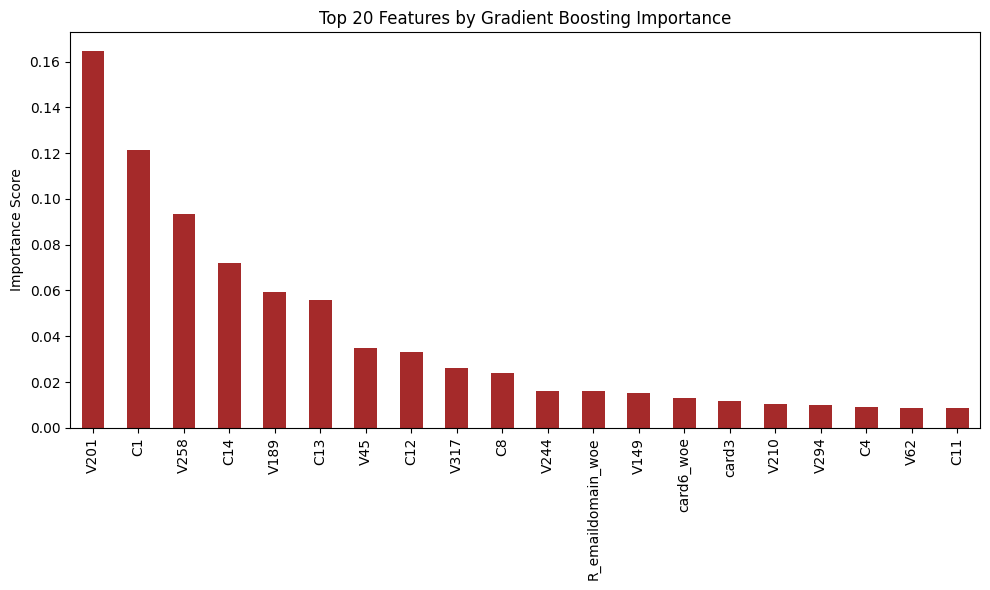

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
from sklearn.ensemble import GradientBoostingClassifier

gb_base = GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42)
gb_base.fit(X_train_clean, y_train)

importances= pd.Series(gb_base.feature_importances_, index=X_train_clean.columns)
importances_sorted = importances.sort_values(ascending=False)

gb_selected_features =importances_sorted.head(20).index.tolist()

print("\ntop 20 Features selected by ggradient boosting Importance:")
for i, feature in enumerate(gb_selected_features, 1):
    print(f"{i}. {feature} (Score: {importances_sorted[feature]:.4f})")

plt.figure(figsize=(10, 6))
importances_sorted.head(20).plot(kind='bar',color='brown')
plt.title('Top 20 Features by Gradient Boosting Importance')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig("gb_importances.png")

with mlflow.start_run(run_name="GradientBoosting_Feature_Selection"):
    
    mlflow.log_param("selection_method","GradientBoosting_Feature_Importance")
    mlflow.log_param("num_features_selected",len(gb_selected_features))
    
    for i, feature in enumerate(gb_selected_features, 1):
        mlflow.log_param(f"selected_feature_{i}", feature)
        
    mlflow.log_artifact("gb_importances.png")

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold
import mlflow.sklearn
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import GradientBoostingClassifier

class FinalCustomPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, woe_columns, one_hot_columns, final_columns):
        self.woe_columns =woe_columns 
        self.one_hot_columns= one_hot_columns 
        self.final_columns =final_columns 

    def fit(self, X, y):
        self.woe_columns_fill_na = X[self.woe_columns].mode().iloc[0].to_dict()
        num_cols = X.select_dtypes(include=[np.number]).columns
        self.numerical_medians = X[num_cols].median().to_dict()
        
        df_woe = X.copy()
        df_woe['target'] = y.values

        woe_mappings = {}
        for col in self.woe_columns:
            groups = df_woe.groupby([col])['target'].agg(['count', 'sum'])
            groups.columns = ['n_obs', 'n_pos']
            groups['n_neg'] = groups['n_obs']-groups['n_pos']
            groups['prop_pos']= groups['n_pos']/groups['n_pos'].sum()
            groups['prop_neg'] = groups['n_neg']/groups['n_neg'].sum()
            groups['woe'] =np.log(groups['prop_pos']/groups['prop_neg'])
            groups.replace([np.inf, -np.inf], 0, inplace=True)
            groups.fillna(0, inplace=True)
            woe_mappings[col] = groups['woe'].to_dict()

        self.woe_mappings=woe_mappings
        return self

    def transform(self, X):
        X_transformed = X.copy()
        
        for col in self.woe_columns:
            if col in X_transformed.columns:
                X_transformed[f'{col}_woe'] = X_transformed[col].map(self.woe_mappings.get(col, {}))
                X_transformed.drop(columns=col, inplace=True)

        existing_ohe =[col for col in self.one_hot_columns if col in X_transformed.columns]
        if existing_ohe:
            X_transformed =pd.get_dummies(X_transformed, columns=existing_ohe, drop_first=True, dummy_na=True, dtype=int)

        for col in self.woe_columns:
            woe_col_name = f'{col}_woe'
            if woe_col_name in X_transformed.columns and X_transformed[woe_col_name].isna().any():
                mode_val =self.woe_columns_fill_na.get(col)
                fill_val= self.woe_mappings[col].get(mode_val, 0)
                X_transformed[woe_col_name] = X_transformed[woe_col_name].fillna(fill_val)

        for col, median_val in self.numerical_medians.items():
            if col in X_transformed.columns:
                X_transformed[col] = X_transformed[col].fillna(median_val)

        for col in self.final_columns:
            if col not in X_transformed.columns:
                X_transformed[col] = 0

        return X_transformed[self.final_columns]

pipeline = Pipeline([
    ('preprocess', FinalCustomPreprocessor(woe_columns=woe_columns, 
                                           one_hot_columns=one_hot_columns, 
                                           final_columns=gb_selected_features)), 
    ('classifier',GradientBoostingClassifier(random_state=42))
])


kfold = KFold(n_splits=3,shuffle=True, random_state=42) 

param_grid = {
    'classifier__learning_rate': [0.05, 0.1],  
    'classifier__n_estimators': [100],        
    'classifier__max_depth': [3, 5]          
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=kfold,
    scoring='roc_auc',
    verbose=2,
    return_train_score=True,
    n_jobs=-1
)

with mlflow.start_run(run_name="GradientBoosting_CrossValidation"):
    
    mlflow.log_params({
        "cv_folds": kfold.n_splits,
        "scoring_metric": "roc_auc",
        "model_type": "GradientBoosting"
    })
    
    grid_search.fit(X_train, y_train)
    
    mlflow.log_param("best_learning_rate",grid_search.best_params_['classifier__learning_rate'])
    mlflow.log_param("best_n_estimators",grid_search.best_params_['classifier__n_estimators'])
    mlflow.log_param("best_max_depth", grid_search.best_params_['classifier__max_depth'])
    
    mlflow.log_metric("best_cv_roc_auc", grid_search.best_score_)
    
    print(f"\nnest parameters found: {grid_search.best_params_}")
    print(f"best cv roc auc score: {grid_search.best_score_:.4f}")
    
    mlflow.sklearn.log_model(grid_search.best_estimator_,"best_pipeline_model_gradientBoosting")

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = geta

[CV] END classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=100; total time= 1.1min
[CV] END classifier__learning_rate=0.05, classifier__max_depth=5, classifier__n_estimators=100; total time= 1.6min


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylik


nest parameters found: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}
best cv roc auc score: 0.8574


2026/05/04 20:07:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run GradientBoosting_CrossValidation at: https://dagshub.com/tvada22/ML--Assignment2-IEEE-CIS-Fraud-Detection.mlflow/#/experiments/5/runs/c2ca64422fae40f0866c71a038fffd34
🧪 View experiment at: https://dagshub.com/tvada22/ML--Assignment2-IEEE-CIS-Fraud-Detection.mlflow/#/experiments/5


In [9]:
import pandas as pd

test_df = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv')
test_df = reduce_mem_usage(test_df)

submission_ids = test_df['TransactionID']
X_test_raw = test_df.drop(columns=['TransactionID', 'TransactionDT'])
pred_probs = grid_search.best_estimator_.predict_proba(X_test_raw)[:, 1]

submission = pd.DataFrame({
    'TransactionID': submission_ids,
    'isFraud': pred_probs
})

submission.to_csv('/kaggle/working/submission.csv', index=False)

memory usage of dataframe is 1519.24 MB
[CV] END classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=100; total time= 1.0min
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=100; total time=  58.9s
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=100; total time= 1.0min


/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2587083322.py:21: RuntimeWarning: overfl

memory usage after optimization is: 472.59 MB
decreased by 68.9%
[CV] END classifier__learning_rate=0.1, classifier__max_depth=5, classifier__n_estimators=100; total time= 1.3min
[CV] END classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=100; total time= 1.0min
[CV] END classifier__learning_rate=0.05, classifier__max_depth=5, classifier__n_estimators=100; total time= 1.6min
[CV] END classifier__learning_rate=0.1, classifier__max_depth=5, classifier__n_estimators=100; total time= 1.4min
[CV] END classifier__learning_rate=0.05, classifier__max_depth=5, classifier__n_estimators=100; total time= 1.6min
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=100; total time= 1.0min
[CV] END classifier__learning_rate=0.1, classifier__max_depth=5, classifier__n_estimators=100; total time= 1.4min
